# HyWindSea SANTANDER - Reconstruction

Hindcast of the bay from ERA5 winds alone, for a period with no SWAN runs, and
the case-study figure: regional forcing, local wave response, and the series
against the tide gauge.

**Reads** `inputs/wind_era5_full.nc`, `inputs/mareografo_spectral_bands_tm02.nc`, `inputs/ortofoto.png`, `inputs/linea_costa/`, `outputs/SANTANDER/{pca,rbf}/`
**Writes** nothing - figures only

In [1]:
import geopandas as gpd
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.core.io import load_model

from utils.plotting import plot_case_study, set_paper_style

set_paper_style()

In [2]:
SITE = "SANTANDER"
TIDE = "pos0m"

WIND_FILE = "inputs/wind_era5_full.nc"
GAUGE_FILE = "inputs/mareografo_spectral_bands_tm02.nc"
ORTHO_FILE = "inputs/ortofoto.png"
COAST_FILE = "inputs/linea_costa/Europe_coastline_shapefile_lonlat.shp"

PCA_DIR = f"outputs/{SITE}/pca"
RBF_DIR = f"outputs/{SITE}/rbf"

VAR = "Hsig_rescaled"
VAR_LABEL = "Hsig (m)"
GAUGE_VAR = "Hm0_sea"             # wind-sea band only, the part SWAN simulates

# Window to reconstruct and show. The gauge spectral file covers 2024 only.
WINDOW = ("2024-10-01", "2024-10-12")

GAUGE_LON, GAUGE_LAT = -3.79, 43.46
CHUNK = 500

> ⚠️ **What is missing relative to the original Figure 7**
>
> That figure combined four tide levels through `tide_assignment.csv` and added
> the REDMAR agitation record. Neither is in this repository, so this version
> reconstructs at a single tide level (`pos0m`) and compares against the tide
> gauge alone. The layout and the reading are the same; the tide-aware version
> needs the other reconstructions first.

## Load

In [3]:
pca_wind = load_model(f"{PCA_DIR}/pca_era5.pkl")
pca_wave = load_model(f"{PCA_DIR}/pca_{VAR}_{TIDE}.pkl")
rbf = load_model(f"{RBF_DIR}/rbf_{VAR}_{TIDE}.pkl")

wind = xr.open_dataset(WIND_FILE).sel(time=slice(*WINDOW))

# ERA5 stores longitudes in [0, 360]. The bay, the coastline and the orthophoto
# are all in [-180, 180], so without this the wind panels sit on a different
# axis and neither the coastline nor the domain box lands on them.
wind = wind.assign_coords(lon=(((wind.lon + 180) % 360) - 180)).sortby("lon")
gauge = xr.open_dataset(GAUGE_FILE).sel(time=slice(*WINDOW))

coastline = gpd.read_file(COAST_FILE)
orthophoto = mpimg.imread(ORTHO_FILE)

print(f"window     : {WINDOW[0]} to {WINDOW[1]}")
print(f"ERA5 hours : {wind.sizes['time']:,}")
print(f"gauge hours: {gauge.sizes['time']:,}")

window     : 2024-10-01 to 2024-10-12
ERA5 hours : 288
gauge hours: 226


## Reconstruct

The wind PCA is not refitted: `transform` projects the new winds onto the
components that were already fitted, which is what keeps the reconstruction
consistent with the RBF trained on them.

In [4]:
times = pd.to_datetime(wind.time.values)
wind_pcs = pd.DataFrame(
    pca_wind.transform(data=wind).PCs.values,
    index=times,
    columns=pca_wind.pcs_df.columns,
)

pieces = []
for start in range(0, len(wind_pcs), CHUNK):
    block = wind_pcs.iloc[start:start + CHUNK]
    pcs = rbf.predict(block)
    field = pca_wave.inverse_transform(
        PCs=xr.Dataset(
            {"PCs": (("time", "n_component"), pcs.values)},
            coords={"time": block.index.values},
        )
    )
    pieces.append(field[VAR].load())

wave = xr.concat(pieces, dim="time").sortby("time")
print(f"reconstructed: {dict(wave.sizes)}")

INFO:PCA:Transforming data using PCA model
INFO:PCA:Adding windows in PCA dimension for rows
INFO:PCA:Generating stacked data matrix
INFO:PCA:Generating data matrix with variables to stack: ['u10', 'v10'] and coordinates to stack: ['lat', 'lon']
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
INFO:PCA:Data matrix generated successfully with shape: (288, 40)
INFO:PCA:Standarizing data matrix
INFO:PCA:Data preprocessed successfully
INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating

reconstructed: {'time': 288, 'lat': 182, 'lon': 219}


In [5]:
at_gauge = wave.sel(lon=GAUGE_LON, lat=GAUGE_LAT, method="nearest").to_series()
observed = gauge[GAUGE_VAR].to_series()

series = pd.concat(
    {"tide gauge (wind sea)": observed, "metamodel": at_gauge}, axis=1
).dropna()

error = series["metamodel"] - series["tide gauge (wind sea)"]
print(f"n    : {len(series)}")
print(f"corr : {series.corr().iloc[0, 1]:.3f}")
print(f"RMSE : {np.sqrt((error ** 2).mean()):.3f} m")
print(f"bias : {error.mean():+.3f} m")

n    : 226
corr : 0.369
RMSE : 0.057 m
bias : +0.015 m


## Case study

One quiet hour and one energetic hour, picked from the observations rather than
chosen by hand so the figure cannot be tuned to flatter the model.

In [6]:
observed_series = series["tide gauge (wind sea)"]
storm = observed_series.idxmax()

# Take the quiet hour from a different day, or both panels would show the same
# synoptic situation a few hours apart.
other_days = observed_series[observed_series.index.normalize() != storm.normalize()]
quiet = other_days.idxmin()

print(f"quiet: {quiet:%Y-%m-%d %H:%M}  observed {observed_series[quiet]:.3f} m")
print(f"storm: {storm:%Y-%m-%d %H:%M}  observed {observed_series[storm]:.3f} m")

quiet: 2024-10-05 21:00  observed 0.034 m
storm: 2024-10-12 09:00  observed 0.248 m


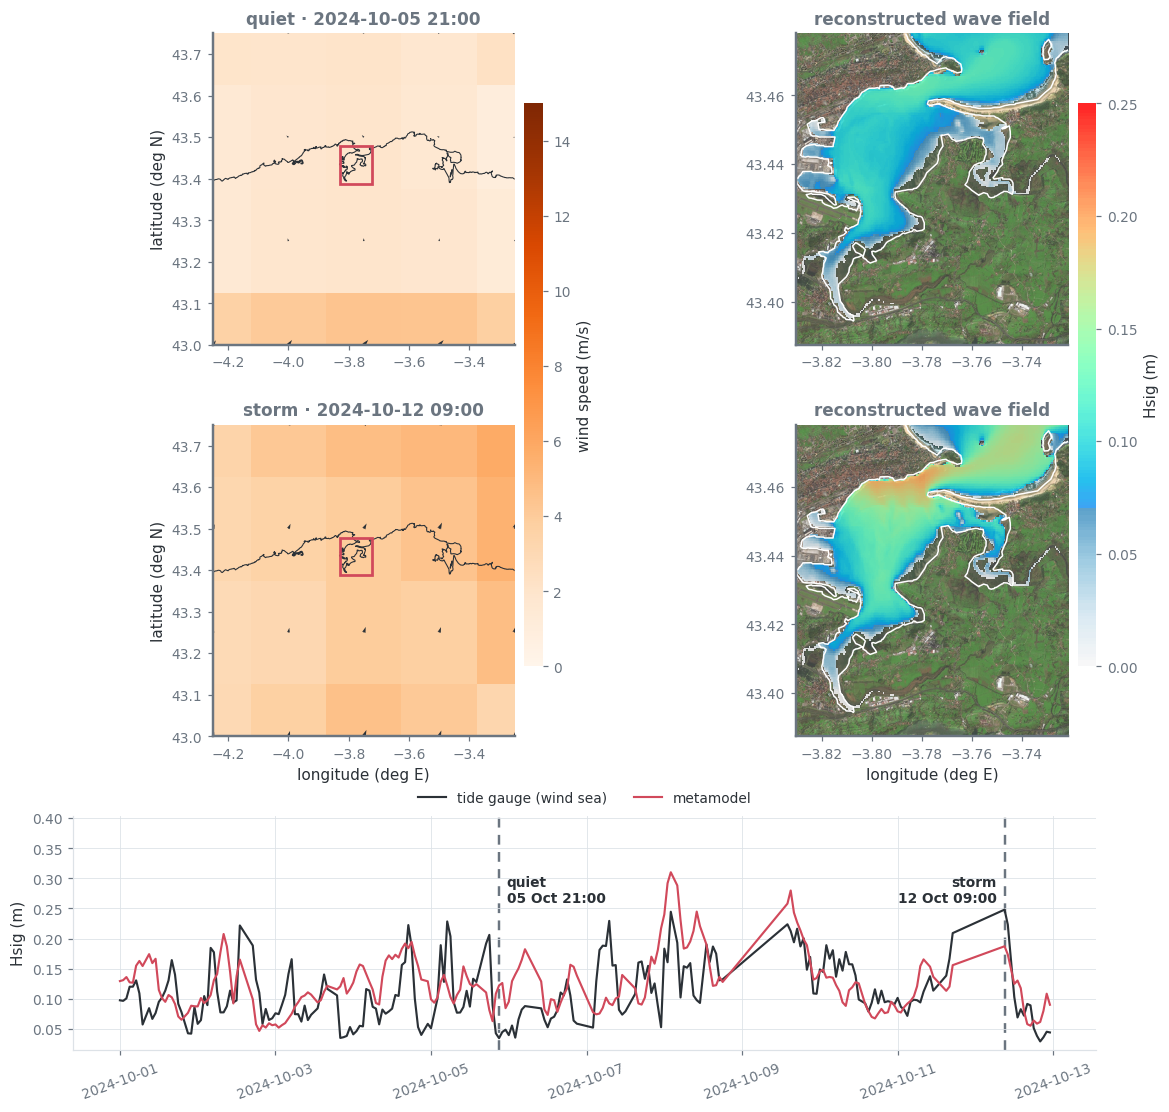

In [7]:
from bluemath_tk.core.plotting.colors import colormap_spectra

plot_case_study(
    wave=wave,
    wind=wind,
    series=series,
    times=[quiet, storm],
    orthophoto=orthophoto,
    coastline=coastline,
    var_label=VAR_LABEL,
    wave_clim=(0, 0.25),
    wave_cmap=colormap_spectra(),
);